In [1]:
!pip install pandas matplotlib seaborn

In [2]:
import pandas as pd

raw = [
    {"date":"2026-01-01","store":"A","menu":"Americano","price":"4500원","qty":"2","paid":"TRUE"},
    {"date":"2026/01/01","store":"A","menu":"Latte","price":"5,000","qty":1,"paid":"True"},
    {"date":"2026-01-02","store":"A","menu":"Latte","price":None,"qty":2,"paid":"FALSE"},
    {"date":"2026-01-03","store":"B","menu":"Mocha","price":"5500","qty":None,"paid":True},
    {"date":"2026-01-03","store":"B","menu":"Americano","price":"4500","qty":1,"paid":"TRUE"},
    {"date":"2026-01-04","store":"B","menu":"Latte","price":"5000원","qty":"3","paid":"TRUE"},
]
df = pd.DataFrame(raw)
df.head()

,date,store,menu,price,qty,paid
0,2026-01-01,A,Americano,4500원,2,TRUE
1,2026/01/01,A,Latte,"5,000",1,True
2,2026-01-02,A,Latte,None,2,FALSE
3,2026-01-03,B,Mocha,5500,None,True
4,2026-01-03,B,Americano,4500,1,TRUE


In [3]:
import numpy as np

# 날짜
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# price 숫자화
df["price"] = (df["price"].astype("string")
               .str.replace(",","", regex=False)
               .str.replace("원","", regex=False))
df["price"] = pd.to_numeric(df["price"], errors="coerce")

# qty 숫자화
df["qty"] = pd.to_numeric(df["qty"], errors="coerce")

# paid bool로 통일
df["paid"] = (df["paid"].astype("string").str.upper() == "TRUE")

# 매출
df["sales"] = df["price"] * df["qty"]

df

,date,store,menu,price,qty,paid,sales
0,2026-01-01,A,Americano,4500,2.0,True,9000.0
1,NaT,A,Latte,5000,1.0,True,5000.0
2,2026-01-02,A,Latte,<NA>,2.0,False,<NA>
3,2026-01-03,B,Mocha,5500,NaN,True,<NA>
4,2026-01-03,B,Americano,4500,1.0,True,4500.0
5,2026-01-04,B,Latte,5000,3.0,True,15000.0


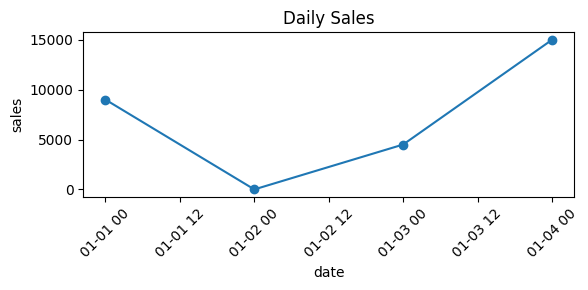

In [11]:
import matplotlib.pyplot as plt 

daily = df.groupby("date", as_index=False)["sales"].sum()
plt.figure(figsize=(6,3))
plt.plot(daily["date"], daily["sales"], marker="o")
plt.title("Daily Sales")
plt.xlabel("date")
plt.ylabel("sales")
plt.xticks(rotation=45)
plt.tight_layout() 
plt.show()

해석 템플릿
- 관찰: 01-01 대비 01-04 때 매출이 증가했다
- 추정: 수량/결제성공/가격 변화가 원인일 수 있어 추가확인이 필요하다

미션
- 매장별로 일별 매출을 나눠서 2개 라인을 그려보기(멀티 라인)
-> 매장별 일별 매출 비교

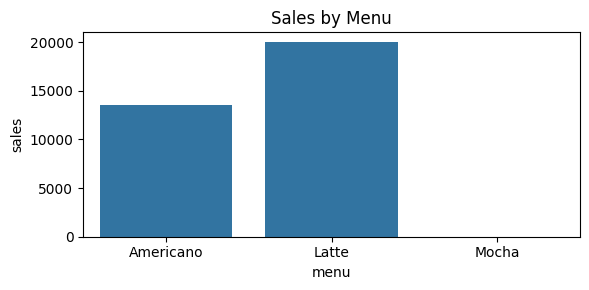

In [12]:
import seaborn as sns

menu_sales = df.groupby("menu",as_index=False)["sales"].sum()

plt.figure(figsize=(6,3))
sns.barplot(data=menu_sales, x="menu", y="sales")
plt.title("Sales by Menu")
plt.tight_layout()
plt.show()

해석 템플릿
- 관찰: 아메리카노보다 라떼의 매출이 더 높다. 모카는 매출이 0이다
- 추정: 단가/판매량을 비교해봐야겠다. 모카는 결측치겠구나

In [13]:
df_a = df[df["store"]=="A"].dropna(subset=["date"]).copy()

df_a

,date,store,menu,price,qty,paid,sales
0,2026-01-01,A,Americano,4500,2.0,True,9000.0
2,2026-01-02,A,Latte,<NA>,2.0,False,<NA>


In [22]:
daily_a = df_a.groupby("date",as_index=False)["sales"].sum()
daily_a

,date,sales
0,2026-01-01,9000.0
1,2026-01-02,0.0


In [14]:
df_b = df[df["store"]=="B"].dropna(subset=["date"]).copy() 
daily_b = df_b.groupby("date",as_index=False)["sales"].sum()
daily_b

,date,sales
0,2026-01-03,4500.0
1,2026-01-04,15000.0


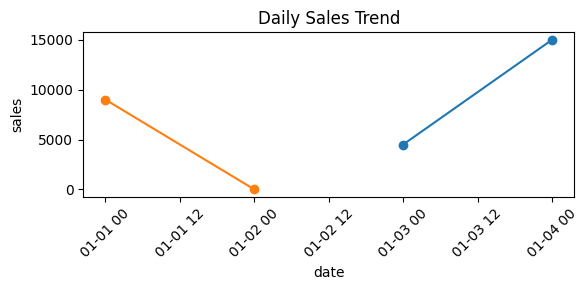

In [16]:
plt.figure(figsize=(6,3))
plt.plot(daily_a["date"], daily_a["sales"], color="tab:orange", marker="o")
plt.plot(daily_b["date"], daily_b["sales"], color="tab:blue", marker="o")
plt.title("Daily Sales Trend")
plt.xlabel("date"); plt.ylabel("sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

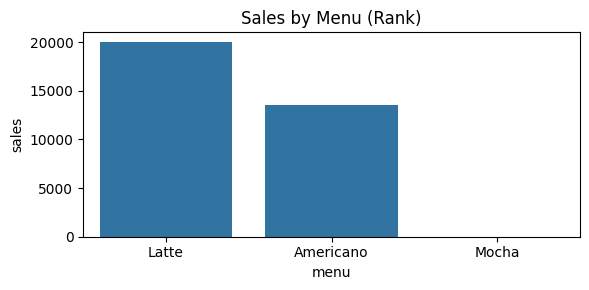

In [17]:
menu_sales = (df.groupby("menu", as_index=False)["sales"]
              .sum()
              .sort_values("sales", ascending=False))

plt.figure(figsize=(6,3))
sns.barplot(data=menu_sales, x="menu", y="sales")
plt.title("Sales by Menu (Rank)")
plt.tight_layout()
plt.show()

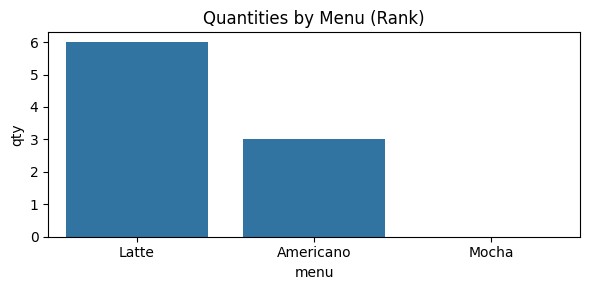

In [18]:
menu_qty = (df.groupby("menu", as_index=False)["qty"]
            .sum()
            .sort_values("qty", ascending=False))

plt.figure(figsize=(6,3))
sns.barplot(data=menu_qty, x="menu", y="qty")
plt.title("Quantities by Menu (Rank)")
plt.tight_layout()
plt.show()

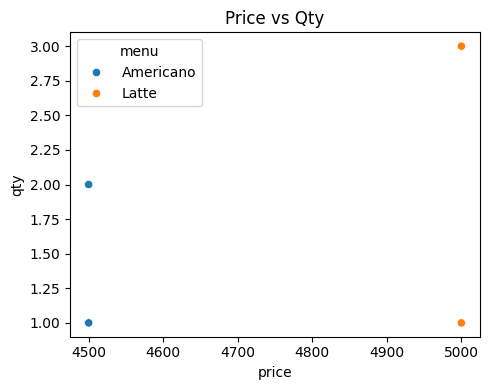

In [20]:
tmp = df.dropna(subset=["price","qty"])

plt.figure(figsize=(5,4))
sns.scatterplot(data=tmp, x="price", y="qty",hue="menu")
plt.title("Price vs Qty")
plt.tight_layout()
plt.show()

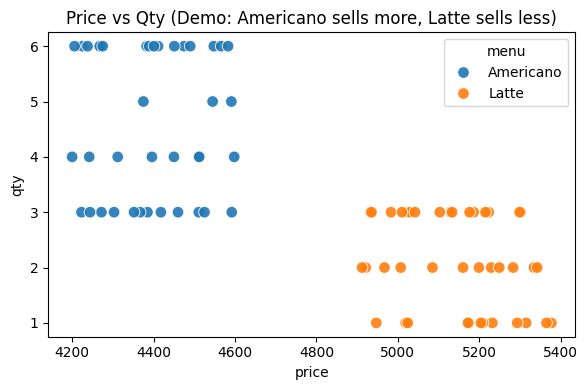

,menu,price,qty,sales
0,Americano,4375,5,21875
1,Americano,4396,4,17584
2,Americano,4225,6,25350
3,Americano,4267,6,25602
4,Americano,4411,6,26466


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(7)

n = 40  # 점 개수(원하는 만큼 늘려도 됨)

# Americano: 저가 + 수량 많음
a_price = np.random.randint(4200, 4601, size=n)
a_qty   = np.random.randint(3, 7, size=n)   # 3~6

# Latte: 고가 + 수량 적음
l_price = np.random.randint(4900, 5401, size=n)
l_qty   = np.random.randint(1, 4, size=n)   # 1~3

df_demo = pd.DataFrame({
    "menu":  ["Americano"] * n + ["Latte"] * n,
    "price": np.concatenate([a_price, l_price]),
    "qty":   np.concatenate([a_qty, l_qty]),
})

# (선택) 판매금액도 같이 보고 싶으면
df_demo["sales"] = df_demo["price"] * df_demo["qty"]

# 산점도
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_demo, x="price", y="qty", hue="menu", s=70, alpha=0.9)

plt.title("Price vs Qty (Demo: Americano sells more, Latte sells less)")
plt.xlabel("price")
plt.ylabel("qty")
plt.tight_layout()
plt.show()

df_demo.head()

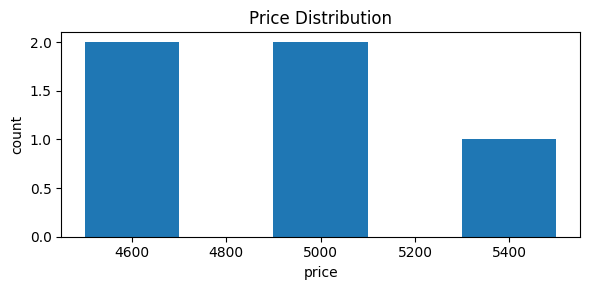

In [23]:
tmp = df.dropna(subset=["price"])

plt.figure(figsize=(6,3))
plt.hist(tmp["price"], bins=5)
plt.title("Price Distribution")
plt.xlabel("price")
plt.ylabel("count")
plt.tight_layout()
plt.show()

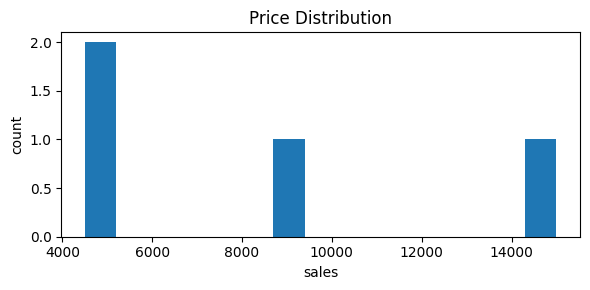

In [26]:
tmp = df.dropna(subset=["sales"])

plt.figure(figsize=(6,3))
plt.hist(tmp["sales"], bins = 15)
plt.title("Price Distribution")
plt.xlabel("sales")
plt.ylabel("count")
plt.tight_layout()
plt.show()

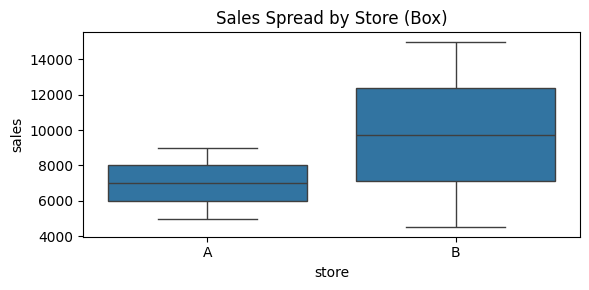

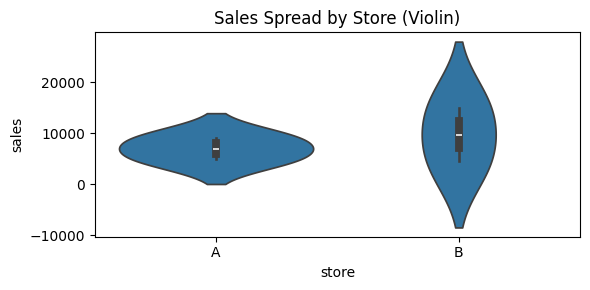

In [27]:
tmp = df.dropna(subset=["sales"])

plt.figure(figsize=(6,3))
sns.boxplot(data=tmp, x="store",  y="sales")
plt.title("Sales Spread by Store (Box)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,3))
sns.violinplot(data=tmp, x="store", y="sales")
plt.title("Sales Spread by Store (Violin)")
plt.tight_layout()
plt.show()

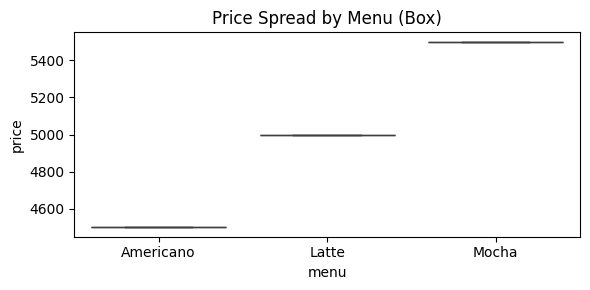

In [28]:
tmp = df.dropna(subset=["price"])

plt.figure(figsize=(6,3))
sns.boxplot(data=tmp, x="menu", y="price")
plt.title("Price Spread by Menu (Box)")
plt.tight_layout()
plt.show()

일별 총매출 추이(Line)

메뉴별 매출 순위(Bar)

가격 vs 수량 관계(Scatter)

매장별 매출 분포(Box 또는 Violin)


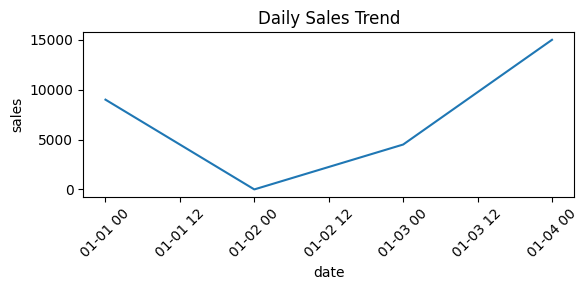

In [ ]:
# 일별 총매출 추이(Line)
plt.figure(figsize=(6,3))
daily = df.groupby("date", as_index=False)["sales"].sum()
plt.plot(daily["date"], daily["sales"])
plt.title("Daily Sales Trend")
plt.xlabel("date")
plt.ylabel("sales")
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()

- 관찰: 01-02일에 매출이 줄어들었다가 다시 증가하는 추세다
- 추정: 01-02일 데이터가 누락이 되었거나 결측이 발생했겠구나 03일엔 매출이 많이 증가했는데 프로모션이 있었던건지 확인이 필요하겠다

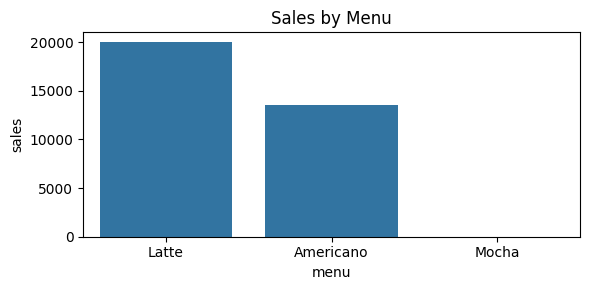

In [31]:
# 메뉴별 매출 순위(Bar)
menu_sales = (df.groupby("menu", as_index=False)["sales"]
                .sum()
                .sort_values("sales", ascending=False))
plt.figure(figsize=(6,3))
sns.barplot(data=menu_sales, x="menu", y="sales")
plt.title("Sales by Menu")
plt.tight_layout()
plt.show()

- 관찰: 라떼의 매출이 가장 크고 그 다음은 아메리카노네
- 추정: 라떼의 단가가 높은걸 수도 있겠다 단가와 판매 수량을 확인해봐야겠다

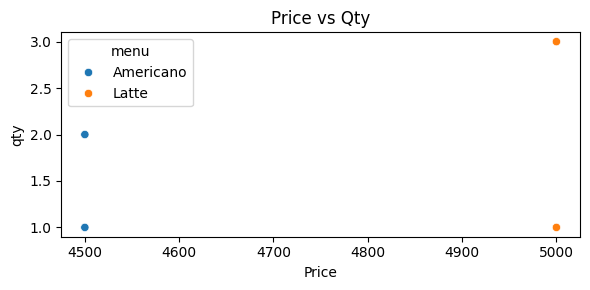

In [35]:
# 가격 vs 수량 관계(Scatter)
tmp = df.dropna(subset=["price","qty"]) # 결측 제거!!!

plt.figure(figsize=(6,3))
sns.scatterplot(data=tmp, x="price", y="qty", hue="menu")
plt.title("Price vs Qty")
plt.xlabel("Price")
plt.ylabel("qty")
plt.tight_layout()
plt.show()

- 관찰: 라떼의 단가가 5000원이고 아메리카노의 단가가 4500원이었네 라떼는 단가가 높지만 판매 수량은 가격과 상관없이 높게 나왔네 아까 위에서 본 메뉴별 매출 그래프에서 라떼가 높게 나온 이유가 여기 있었군
- 추정: 아직 데이터가 얼마 없어서 예외 상황이 나온 걸수도 있으니 데이터가 더 필요하겠다. 더 많은 데이터가 쌓이면 가격과 판매 수량간의 상관관계를 좀 더 정확히 분석할 수 있겠다
- 추가적 인사이트: B매장의 데이터를 더 구했을 때 라떼 매출이 여전히 높게 측정된다면, B매장 경영자에게 라떼 중심의 세트 메뉴를 더 구성하자고 제안할 수 있음(가격을 올리다간 역효과로 매출이 감소할 수도 있어)

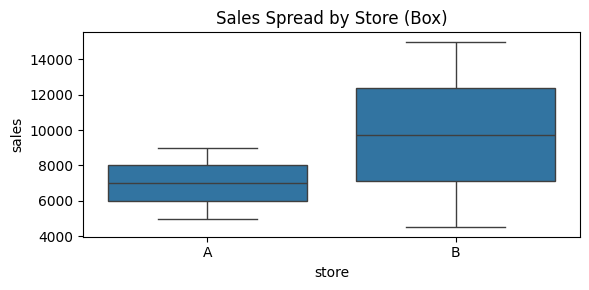

In [36]:
# 매장별 매출 분포(Box 또는 Violin)
tmp = df.dropna(subset=["sales"])

plt.figure(figsize=(6,3))
sns.boxplot(data=tmp, x="store", y="sales")
plt.title("Sales Spread by Store (Box)")
plt.tight_layout()
plt.show()

- 관찰: B 매장의 판매량이 더 범위가 넓게 나왔네 평균과 중간값도 A매장보다 B매장이 더 높게 나왔네
- 추정: B 매장의 매출이 더 높게 나온 이유가 무엇일까. 단가를 높게 잡았을까 아니면 단가가 높은 음료의 주문이 많았을까 그 이유는 뭘까 프로모션이 있었을까 아니면 지리적으로 유리했을까
- 추가적 인사이트: B매장의 매출 범위가 넓다는 것은 변동성이 크다는 것!